In [2]:
from pathlib import Path
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "groceries-5k" / "dataset"

image_path = DATASET_ROOT / "images" / "nuts" / "NUTS0042.png"
annotation_path = DATASET_ROOT / "annotations" / "nuts" / "NUTS0042.xml"

print(image_path)
print(annotation_path)

print("Image exists:", image_path.exists())
print("Annotation exists:", annotation_path.exists())

/home/sanket/retail-product-detection/data/raw/groceries-5k/dataset/images/nuts/NUTS0042.png
/home/sanket/retail-product-detection/data/raw/groceries-5k/dataset/annotations/nuts/NUTS0042.xml
Image exists: True
Annotation exists: True


In [4]:
tree = ET.parse(annotation_path)
root = tree.getroot()

print(root.tag)

annotation


In [6]:
filename = root.find("filename").text

width = int(root.find("size/width").text)
height = int(root.find("size/height").text)

print("Filename:", filename)
print("Width:", width)
print("Height:", height)

Filename: NUTS0042.png
Width: 224
Height: 224


In [7]:
objects = []

for obj in root.findall("object"):
    class_name = obj.find("name").text
    truncated = int(obj.find("truncated").text)
    difficult = int(obj.find("difficult").text)

    bbox = obj.find("bndbox")

    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    objects.append({
        "class": class_name,
        "xmin": xmin,
        "ymin": ymin,
        "xmax": xmax,
        "ymax": ymax,
        "truncated": truncated,
        "difficult": difficult
    })

objects

[{'class': 'nuts',
  'xmin': 108,
  'ymin': 67,
  'xmax': 209,
  'ymax': 174,
  'truncated': 0,
  'difficult': 0},
 {'class': 'nuts',
  'xmin': 1,
  'ymin': 55,
  'xmax': 109,
  'ymax': 172,
  'truncated': 1,
  'difficult': 0}]

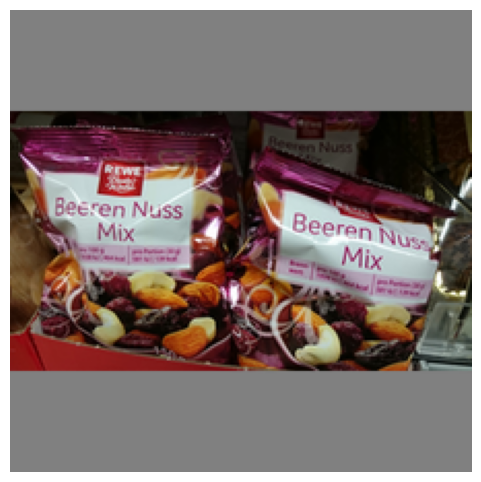

In [8]:
image = Image.open(image_path)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

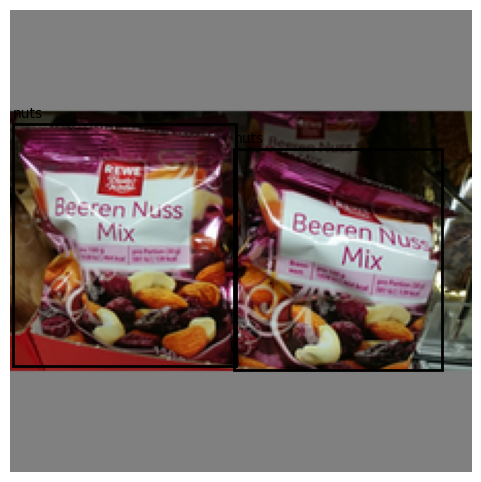

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(image)

for obj in objects:
    xmin = obj["xmin"]
    ymin = obj["ymin"]
    xmax = obj["xmax"]
    ymax = obj["ymax"]

    box_width = xmax - xmin
    box_height = ymax - ymin

    rect = patches.Rectangle(
        (xmin, ymin),
        box_width,
        box_height,
        linewidth=2,
        fill=False
    )

    ax.add_patch(rect)

    ax.text(
        xmin,
        ymin - 3,
        obj["class"],
        fontsize=10
    )

ax.axis("off")
plt.show()

## Dataset-wide annotation analysis

Now that one image/annotation pair has been verified visually, inspect all annotations to understand:

- number of images and objects
- class distribution
- objects per image
- truncated objects
- invalid bounding boxes
- missing image/annotation pairs

In [11]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
annotations_root = DATASET_ROOT / "annotations"
xml_files = list(annotations_root.rglob("*.xml"))

print("Number of XML files:", len(xml_files))

Number of XML files: 4947


In [13]:
records = []

for xml_path in xml_files:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)

    for obj in root.findall("object"):
        bbox = obj.find("bndbox")

        records.append({
            "filename": filename,
            "class": obj.find("name").text,
            "image_width": width,
            "image_height": height,
            "xmin": int(bbox.find("xmin").text),
            "ymin": int(bbox.find("ymin").text),
            "xmax": int(bbox.find("xmax").text),
            "ymax": int(bbox.find("ymax").text),
            "truncated": int(obj.find("truncated").text),
            "difficult": int(obj.find("difficult").text),
        })

df = pd.DataFrame(records)
df.head()

,filename,class,image_width,image_height,xmin,ymin,xmax,ymax,truncated,difficult
0,NUTS0042.png,nuts,224,224,108,67,209,174,0,0
1,NUTS0042.png,nuts,224,224,1,55,109,172,1,0
2,NUTS0019.png,nuts,224,224,104,50,209,174,0,0
3,NUTS0019.png,nuts,224,224,8,49,106,170,0,0
4,NUTS0106.png,nuts,224,224,57,92,169,170,0,0


In [14]:
print("Images:", df["filename"].nunique())
print("Objects:", len(df))
print("Classes:", df["class"].nunique())

Images: 4947
Objects: 11663
Classes: 25


In [15]:
objects_per_image = df.groupby("filename").size()
objects_per_image.describe()

count    4947.000000
mean        2.357590
std         1.405496
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        14.000000
dtype: float64

In [16]:
df["truncated"].value_counts()

truncated
0    7187
1    4476
Name: count, dtype: int64

In [17]:
invalid_boxes = df[
    (df["xmin"] < 0) |
    (df["ymin"] < 0) |
    (df["xmax"] > df["image_width"]) |
    (df["ymax"] > df["image_height"]) |
    (df["xmax"] <= df["xmin"]) |
    (df["ymax"] <= df["ymin"])
]

print("Invalid boxes:", len(invalid_boxes))

Invalid boxes: 1


In [18]:
invalid_boxes

,filename,class,image_width,image_height,xmin,ymin,xmax,ymax,truncated,difficult
10319,FISH0041.png,fish,224,224,87,187,87,188,0,0


In [19]:
df["difficult"].value_counts()

difficult
0    11663
Name: count, dtype: int64

In [20]:
df[["image_width", "image_height"]].drop_duplicates()

,image_width,image_height
0,224,224


In [21]:
class_counts = df["class"].value_counts().sort_values(ascending=False)

class_counts

class
juice           848
jam             834
coffee          763
water           735
spices          663
chocolate       649
candy           624
tea             607
soda            532
cereal          472
vinegar         420
tomato_sauce    393
pasta           392
chips           384
milk            384
honey           363
oil             359
fish            337
corn            301
nuts            288
sugar           284
beans           282
cake            280
rice            275
flour           194
Name: count, dtype: int64

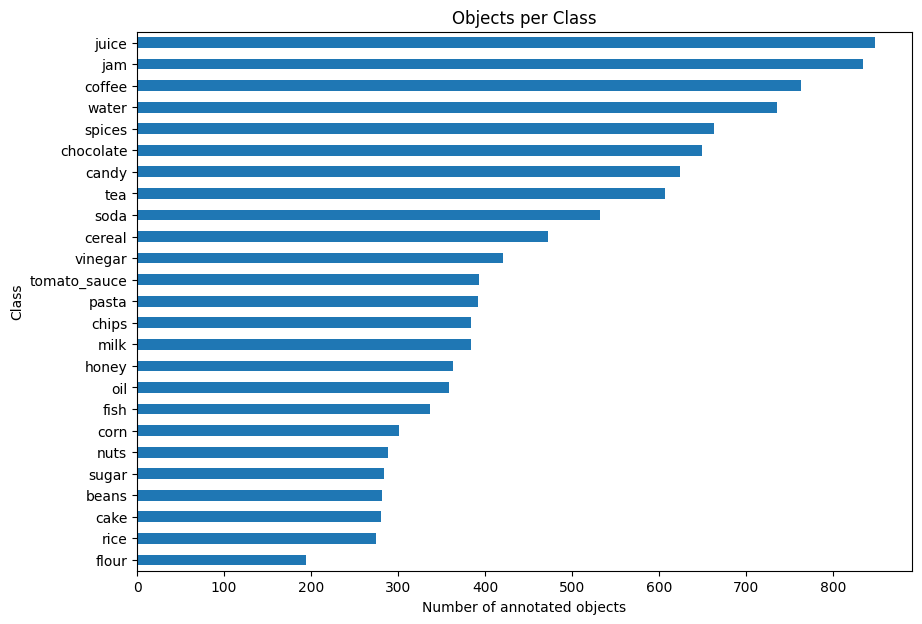

In [22]:
plt.figure(figsize=(10, 7))

class_counts.sort_values().plot(kind="barh")

plt.xlabel("Number of annotated objects")
plt.ylabel("Class")
plt.title("Objects per Class")

plt.show()

In [23]:
print("Largest class:", class_counts.index[0], class_counts.iloc[0])
print("Smallest class:", class_counts.index[-1], class_counts.iloc[-1])
print("Largest / smallest ratio:", class_counts.iloc[0] / class_counts.iloc[-1])

Largest class: juice 848
Smallest class: flour 194
Largest / smallest ratio: 4.371134020618556


In [24]:
class_counts.describe()

count     25.00000
mean     466.52000
std      193.59152
min      194.00000
25%      301.00000
50%      392.00000
75%      624.00000
max      848.00000
Name: count, dtype: float64

In [25]:
image_df = (
    df.groupby("filename")
    .agg(
        class_name=("class", "first"),
        num_objects=("class", "size")
    )
    .reset_index()
)

image_df.head()

,filename,class_name,num_objects
0,BEANS0000.png,beans,1
1,BEANS0001.png,beans,2
2,BEANS0002.png,beans,1
3,BEANS0003.png,beans,5
4,BEANS0004.png,beans,1


In [26]:
print(len(image_df))
print(image_df["class_name"].nunique())

4947
25


In [28]:
from sklearn.model_selection import train_test_split

In [29]:
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.20,
    random_state=42,
    stratify=image_df["class_name"]
)

In [30]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["class_name"]
)

In [31]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 3957
Validation: 495
Test: 495


In [32]:
print("Train classes:", train_df["class_name"].nunique())
print("Val classes:", val_df["class_name"].nunique())
print("Test classes:", test_df["class_name"].nunique())

Train classes: 25
Val classes: 25
Test classes: 25


In [33]:
classes_per_image = df.groupby("filename")["class"].nunique()

print(classes_per_image.value_counts())

class
1    4947
Name: count, dtype: int64


In [34]:
print("Train classes:", train_df["class_name"].nunique())
print("Val classes:", val_df["class_name"].nunique())
print("Test classes:", test_df["class_name"].nunique())

Train classes: 25
Val classes: 25
Test classes: 25


In [35]:
split_distribution = pd.concat([
    train_df["class_name"].value_counts().rename("train"),
    val_df["class_name"].value_counts().rename("val"),
    test_df["class_name"].value_counts().rename("test")
], axis=1).fillna(0).astype(int)

split_distribution

,train,val,test
class_name,,,
candy,297,38,37
chocolate,245,31,31
juice,241,30,31
coffee,238,30,30
tea,226,29,28
cereal,222,28,28
water,210,26,26
jam,193,24,24
spices,166,21,20
